In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from geodatasets import get_path
import pandas as pd
from datetime import datetime, timedelta
import numpy as np


Coordinates of each continent for the "firecontinent" function:

In [2]:
#Mappable parts of the world (their coordinates), add your individual coordinates here if you wish
earth = {"xmin": -169, "xmax": 180, "ymin": -60, "ymax": 90}
europe = {"xmin": -10, "xmax": 40, "ymin": 35, "ymax": 75}
north_america = {"xmin": -170, "xmax": -50, "ymin": 5, "ymax": 75}
south_america = {"xmin": -90, "xmax": -30, "ymin": -60, "ymax": 15}
africa = {"xmin": -20, "xmax": 55, "ymin": -35, "ymax": 38}
asia = {"xmin": 25, "xmax": 180, "ymin": 0, "ymax": 80}
australia = {"xmin": 110, "xmax": 180, "ymin": -50, "ymax": -5}
antarctica = {"xmin": -180, "xmax": 180, "ymin": -90, "ymax": -60}

Datefunction and function to find continent specific data:

In [3]:
#Date function for title -> returns a string that states the start date - end date. 
#The start date is defined through the input variable (xdays_in_the_past) which is the number of days that will be subtracted from today's date.
#Example: xdays_in_the_past=10 and today's date is the 15.05.2026 -> output: 5. May 2026 - 15. May 2026

def datefunction(xdays_in_the_past):
    todays_date = datetime.today()
    start_date = ((todays_date - timedelta(days=xdays_in_the_past)).date()).strftime("%d. %B %Y")
    end_date = (todays_date.date()).strftime("%d. %B %Y")
    date_span = (f"{start_date} - {end_date}")
    
    return date_span

In [4]:
#continent extend function (controls how where fire is drawn on map) by creating "clipped_df" that only has the data from our chosen continent
#The variable (continent_extend) controlls what part(continent) of the map gets created, coords get looked up in data from cell 2
#Example: continet_extend = europe -> function looks up coords and returns df with relevant data
def firecontinent (continent_extend):
    clipped_df = FIRMS_df[
        (FIRMS_df["latitude"] >= continent_extend["ymin"]) &
        (FIRMS_df["latitude"] <= continent_extend["ymax"]) &
        (FIRMS_df["longitude"] >= continent_extend["xmin"]) &
        (FIRMS_df["longitude"] <= continent_extend["xmax"])
]
    return clipped_df

Loads the new data (must always load to get current data):

In [5]:
#Loading the Worldmap, API and reading the data
# Load world basemap from "geodatasets"
world = gpd.read_file(get_path("naturalearth.land"))


# My API key for the last five days of data from the VIIRS S-NPP satellite sensor
API_KEY = "875c5f8321acb83297f0d59448343c67"

url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{API_KEY}/VIIRS_SNPP_NRT/world/5"

FIRMS_df = pd.read_csv(url)

World map with Pointdata and frp as a colour variable to accurately display every single fire and legend that states top 3 countries with the most registred firepoints:

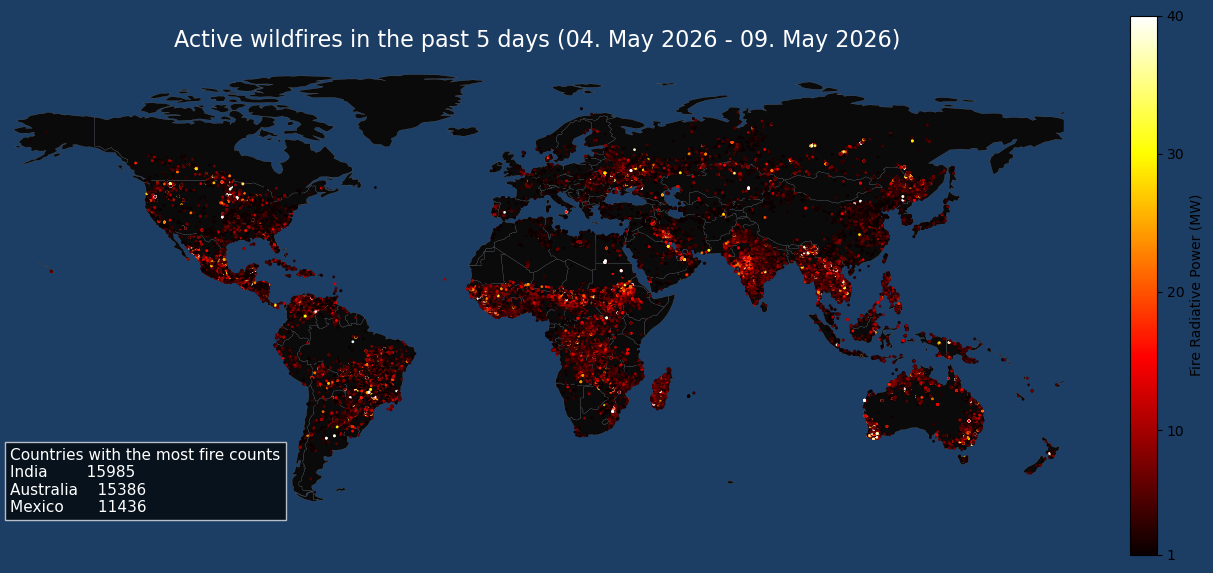

In [6]:
#type in the continent to visualize after "continent_extend = ..." (lowercase with _ instead of spaces)
continent_extent = earth
continental_fires_df = firecontinent(continent_extent)

#maps the world with countryborders
world = gpd.read_file("data/countryborders/ne_110m_admin_0_countries.shp")

#converts Pandas df into GeoDataFrame so that it can be plotted with the Point data by taking x and y from continental_fires_df
continental_fires_df = gpd.GeoDataFrame(continental_fires_df,geometry=gpd.points_from_xy(continental_fires_df["longitude"], continental_fires_df["latitude"]),crs="EPSG:4326")

#Making the top 3 fire countries:
# Assign each fire point to a country
fires_with_countries = gpd.sjoin(continental_fires_df,world,predicate="within")
# Count fire detections per country
fire_counts = fires_with_countries["ADMIN"].value_counts()
# Pick out top 3 countries with the most firecounts
top_3_firecountries = fire_counts.head(3).to_string(header=False)


# Map with dark blue background
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor("#1c3d64")

world.plot(
    ax=ax,
    color="#0a0a0a",
    edgecolor="#666464",
    linewidth=0.2
)

#Plotting the firepoints, vmin/max is the span of frp(Mw) that the Points can be in. The vmax is reduced to create a more readable map
continental_fires_df.plot(
    ax=ax,
    column="frp",
    cmap="hot",
    vmin=1,
    vmax=40,
    markersize=1,
    alpha=0.9,
    legend=True,
    legend_kwds={"label": "Fire Radiative Power (MW)", "ticks": [1, 10, 20, 30, 40]}
)

# Map cosmetics (title and removing lon,lat)
ax.set_title(f"Active wildfires in the past 5 days ({datefunction(5)})", fontsize=16, color="white")
ax.set_axis_off()

#clipping map for better visibility
ax.set_xlim(continent_extent["xmin"], continent_extent["xmax"])
ax.set_ylim(continent_extent["ymin"], continent_extent["ymax"])
# Visualize top 3 countries with most wildfires text
ax.text(0.0001, 0.0001,(f"Countries with the most fire counts\n{top_3_firecountries}"), transform=ax.transAxes,

    fontsize=11,
    color="white",

    verticalalignment="bottom",

    bbox=dict(
        facecolor="black",
        alpha=0.7,
        edgecolor="white"))

plt.show()


Dynamic map with aggregated point data in the hexbins and frp as a colour variable to display fires in a visually better readable map that also shows strength of fire (frp) better because span is up to 1000Mw frp:

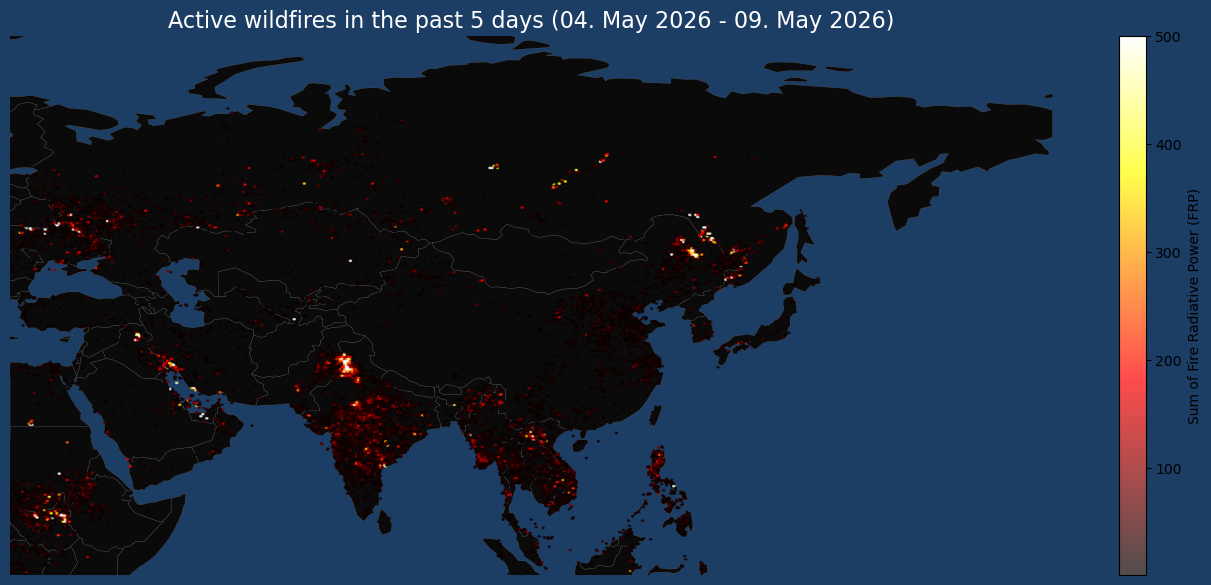

In [7]:
#type in the continent to visualize after "continent_extend = ..." (lowercase with _)
continent_extent = asia
continental_fires_df = firecontinent(continent_extent)

# Map with darkblue background
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor("#1c3d64")

world.plot(
    ax=ax,
    color="#0a0a0a",
    edgecolor="#666464",
    linewidth=0.2
)

#Regulates the max frp to make the map visually clearer
if continent_extent == earth:
    max_frp = 1000
else: 
    max_frp =500

#hexbin map via matplotlib, vmin/max is the span of frp(Mw) that the Points can be in, mincnt is the minimum amount of fires there have to be in order for it to get marked as a fire hexagon.
hexbin_map = ax.hexbin(
    continental_fires_df["longitude"],
    continental_fires_df["latitude"],
    C=continental_fires_df["frp"],
    reduce_C_function=sum,
    gridsize=400,
    vmin=1,
    vmax=max_frp,
    cmap="hot",
    mincnt=1,
    alpha=0.7
)

fig.colorbar(hexbin_map, ax=ax, label="Sum of Fire Radiative Power (FRP)")

# Map cosmetics (title and removing lon,lat)
ax.set_title(f"Active wildfires in the past 5 days ({datefunction(5)})", fontsize=16, color="white")
ax.set_axis_off()

#clipping map for better visibility
ax.set_xlim(continent_extent["xmin"], continent_extent["xmax"])
ax.set_ylim(continent_extent["ymin"], continent_extent["ymax"])
plt.show()
